In [1]:
from itertools import cycle
import pandas as pd
import json
import re
import math
import os
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns

# settings for correcting Type3 font errors on HotCRP
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# change default fonts and font families
matplotlib.rcParams['font.sans-serif'] = "Helvetica"
matplotlib.rcParams['font.family'] = "sans-serif"

# matplotlib.use('Agg') # for running on a server

## Different types of optimizations:

1. Quadratic: 2nd obj is minimizing the variance of the spare capacity at each node. Optimizations are done sequentially for each objective.
1. Linear: 2nd obj is minimizing the abs differences of host utilizations at each node. All three objectives are optimized for at once, in one optimization.
1. Linear-rerun: rerun the linear optimization by just changing the tenant loads
1. Linear-Multiple: 2nd obj is minimizing the abs differences of host utilizations at each node. Optimizations are done sequentially for each objective.
1. Linear2: Do Linear but minimize abs diff of spare capacities instead of host utilizations
1. Linear2-rerun:  rerun the linear2 optimization by just changing the tenant loads

In [2]:
# Initialize an empty list to store each JSON object
data = []

# Read the file line by line
with open("logs/scale_experiment_log.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,result
0,quadratic,1,0,0,119.898081,[],2
1,linear,1,0,0,19.955635,[],2
2,rerun-linear,1,0,0,19.896984,[],2
3,quadratic,3,1,47,31.606674,[2.8750672290056305],2
4,linear,3,1,47,26.937008,[2.8750672290056305],2
...,...,...,...,...,...,...,...
1363,linear,29,18,281,257.346869,"[0.37504650670077133, 1.9576245666889236, 0.09...",2
1364,rerun-linear,29,18,281,254.428387,"[0.5131649036133218, 1.7096122398089613, 0.158...",2
1365,quadratic,30,19,304,148.955822,"[2.699501072104206, 4.034602364471253, 0.51505...",2
1366,linear,30,19,304,310.387850,"[2.699501072104206, 4.034602364471253, 0.51505...",2


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found bec

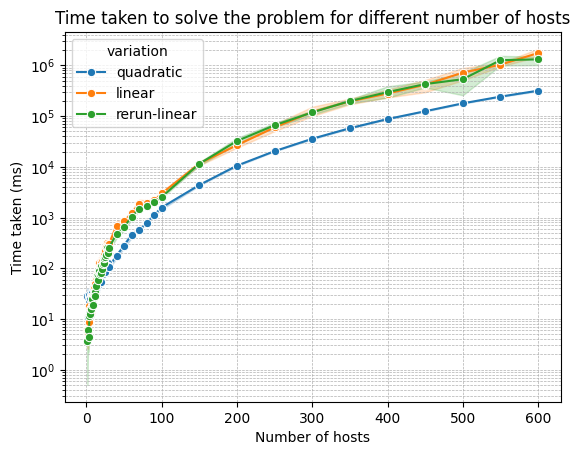

In [3]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

# ax.set_ylim(0, 400)

# ax.set_xlim(0, 500)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

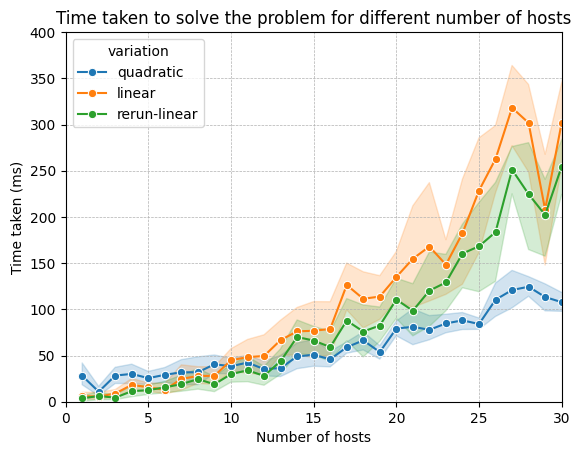

In [4]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('linear')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 400)

ax.set_xlim(0, 30)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [5]:
# Initialize an empty list to store each JSON object
data = []

# Read the file line by line
with open("logs/scale_experiment_linear_multiple_log.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
0,quadratic,1,1,13,66.067934,[1.0233697270540325],"[2, 2, 2]"
1,linear_multiple,1,1,13,22.017717,[1.0233697270540325],"[2, 2, 2]"
2,linear,1,1,13,20.487070,[1.0233697270540325],2
3,rerun-linear,1,1,13,19.808054,[1.3808796951692393],2
4,quadratic,2,1,10,8.862495,[0.5449632478004158],"[2, 2, 2]"
...,...,...,...,...,...,...,...
1075,rerun-linear,29,18,284,261.427402,"[1.5075436754773184, 0.17538809220709742, 1.36...",2
1076,quadratic,30,19,430,161.689281,"[2.102546873943294, 1.7069127041907408, 1.9807...","[2, 2, 2]"
1077,linear_multiple,30,19,430,114.902020,"[2.102546873943294, 1.7069127041907408, 1.9807...","[2, 2, 2]"
1078,linear,30,19,430,488.168478,"[2.102546873943294, 1.7069127041907408, 1.9807...",2


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

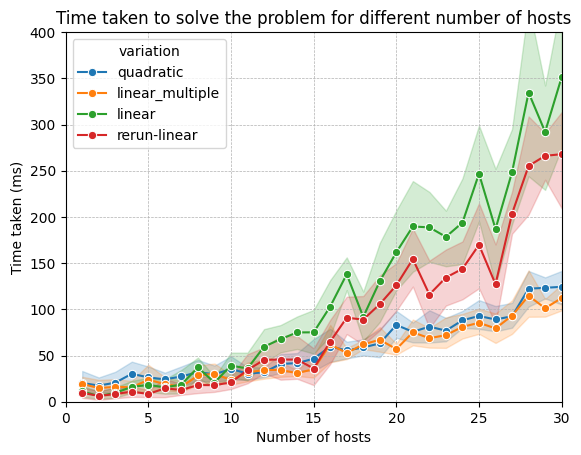

In [6]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('linear')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 400)

ax.set_xlim(0, 30)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [13]:
# Initialize an empty list to store each JSON object
data = []

# Read the file line by line
with open("logs/scale_experiment_linear2.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
0,quadratic,1,1,3,43.902636,[0.16234885100166047],"[2, 2, 2]"
1,linear_multiple,1,1,3,38.612843,[0.16234885100166047],"[2, 2, 2]"
2,linear2,1,1,3,2.003193,[0.16234885100166047],2
3,linear,1,1,3,2.098799,[0.16234885100166047],2
4,rerun-linear,1,1,3,18.957615,[0.027494461602698847],2
...,...,...,...,...,...,...,...
895,quadratic,30,19,184,117.258310,"[0.060426890121028254, 0.1960665934508844, 0.2...","[2, 2, 2]"
896,linear_multiple,30,19,184,114.716768,"[0.060426890121028254, 0.1960665934508844, 0.2...","[2, 2, 2]"
897,linear2,30,19,184,54.349422,"[0.060426890121028254, 0.1960665934508844, 0.2...",2
898,linear,30,19,184,82.975626,"[0.060426890121028254, 0.1960665934508844, 0.2...",2


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

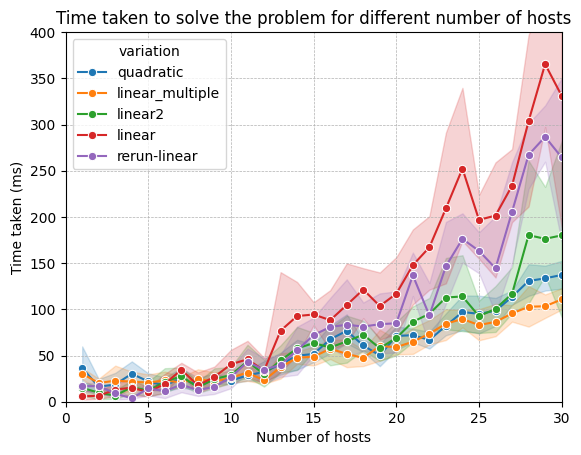

In [14]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('linear')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 400)

ax.set_xlim(0, 30)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [2]:
# Initialize an empty list to store each JSON object
data = []

# Read the file line by line
with open("current_exp.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
0,quadratic,1,1,14,64.067125,[0.9518549983753997],"[2, 2, 2]"
1,linear_multiple,1,1,14,39.601803,[0.9518549983753997],"[2, 2, 2]"
2,linear2,1,1,14,21.002531,[0.9518549983753997],2
3,rerun-linear2,1,1,14,19.476414,[0.7893904581183387],2
4,linear,1,1,14,3.272533,[0.9518549983753997],2
...,...,...,...,...,...,...,...
2047,linear_multiple,450,292,4508,15065.742016,"[0.41725279745465554, 0.23984268678277484, 0.7...","[2, 2, 2]"
2048,linear2,450,292,4508,80001.360178,"[0.41725279745465554, 0.23984268678277484, 0.7...",2
2049,rerun-linear2,450,292,4508,53123.745680,"[0.3643906746196436, 0.08768459036827747, 0.78...",2
2050,linear,450,292,4508,442110.863209,"[0.41725279745465554, 0.23984268678277484, 0.7...",2


In [3]:
df['status'].value_counts()

status
2            1364
[2, 2, 2]     684
11              4
Name: count, dtype: int64

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found bec

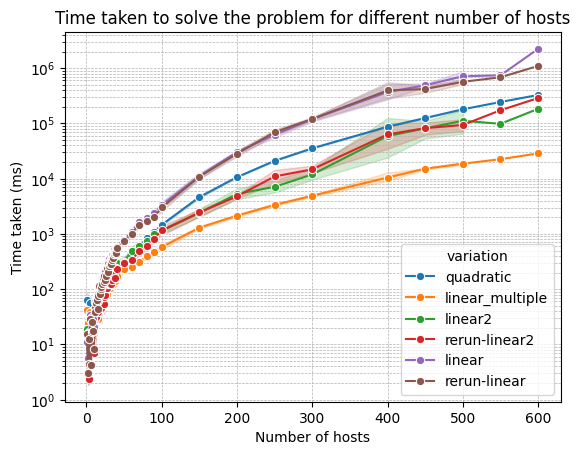

In [5]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

# ax.set_ylim(0, 400)

# ax.set_xlim(0, 40)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

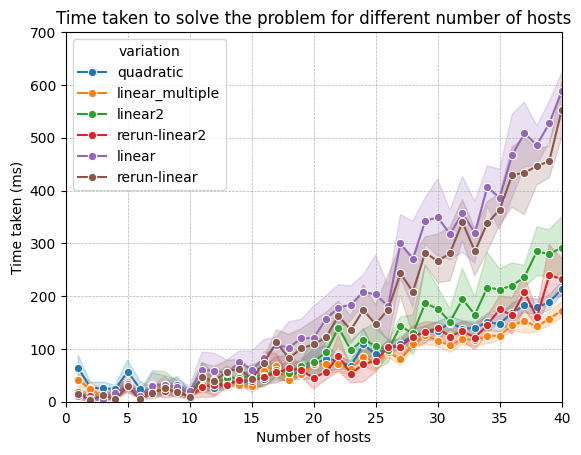

In [15]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
# ax.set_yscale('linear')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 700)

ax.set_xlim(0, 40)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

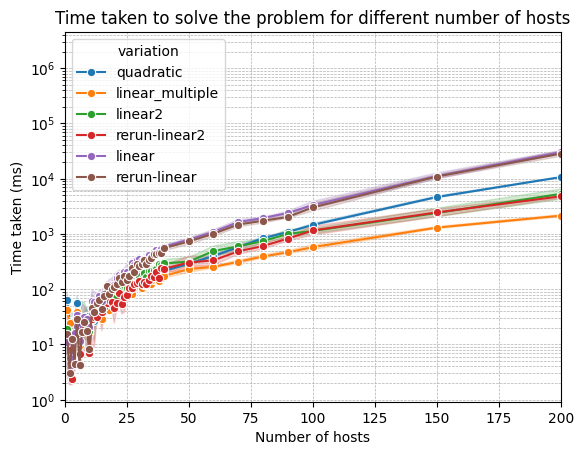

In [14]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

# ax.set_ylim(0, 150)

ax.set_xlim(0, 200)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [16]:
# Initialize an empty list to store each JSON object
data = []

# Read the file line by line
with open("logs/scale_experiment_variating_inputs.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
0,linear_multiple,10,6,183,158.121586,"[3.1711769679394015, 1.9517653725143174, 3.783...","[2, 2, 2]"
1,linear_multiple_some_change,10,6,183,77.768087,"[3.1711769679394015, 1.9517653725143174, 3.783...","[2, 2, 2]"
2,linear_multiple_full_change,10,6,183,204.897642,"[2.159292156564855, 1.762137009787447, 3.09768...","[2, 2, 2]"
3,linear_model2,10,6,183,124.554396,"[3.1711769679394015, 1.9517653725143174, 3.783...",2
4,linear_model2_some_change,10,6,183,70.760250,"[3.1711769679394015, 1.9517653725143174, 3.783...",2
...,...,...,...,...,...,...,...
721,linear_multiple_some_change,400,260,4679,7139.682055,"[2.7295696008188894, 0.7022801670056577, 0.538...","[2, 2, 2]"
722,linear_multiple_full_change,400,260,4679,7376.150846,"[2.8687443125586305, 0.44071284223079, 0.36716...","[2, 2, 2]"
723,linear_multiple,500,325,4930,21073.912859,"[3.8482629780321556e-05, 0.09554420139145955, ...","[2, 2, 2]"
724,linear_multiple_some_change,500,325,4930,79105.470419,"[3.8482629780321556e-05, 0.09554420139145955, ...","[2, 2, 2]"


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

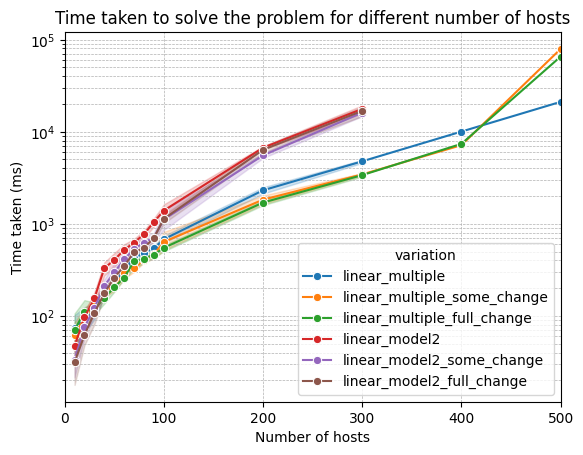

In [21]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

# ax.set_ylim(0, 150)

ax.set_xlim(0, 500)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

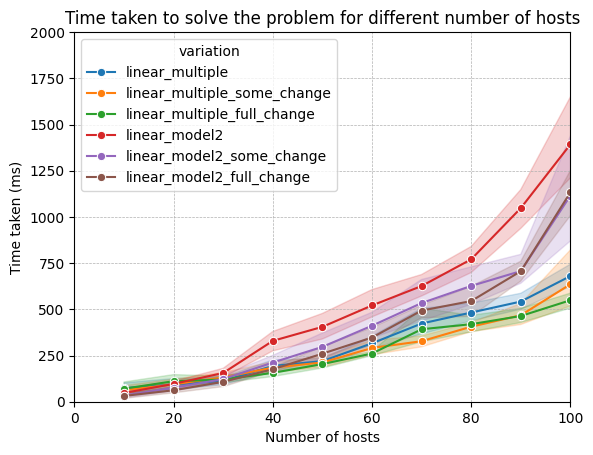

In [18]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
# ax.set_yscale('linear')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 2000)

ax.set_xlim(0, 100)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [20]:
df.loc[df['n_hosts'] == 500].groupby(['variation', 'n_hosts'])[['time_taken']].mean() / 1000

,,time_taken
variation,n_hosts,
linear_multiple,500,21.073913
linear_multiple_full_change,500,65.354358
linear_multiple_some_change,500,79.105470


In [15]:
df.loc[df['n_hosts'] == 300].loc[df['variation'] == 'linear_multiple_some_change']

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
661,linear_multiple_some_change,300,195,3305,3456.280708,"[2.0547292884409045, 3.1485029467868824, 0.043...","[2, 2, 2]"
667,linear_multiple_some_change,300,195,3385,3239.228249,"[0.05774118727867312, 2.147550828677478, 0.173...","[2, 2, 2]"
673,linear_multiple_some_change,300,195,3479,3822.351694,"[6.685207477616323, 1.7803635588922848, 0.2043...","[2, 2, 2]"
679,linear_multiple_some_change,300,195,3206,3358.774424,"[3.1795386886292416, 0.7708678523501475, 0.102...","[2, 2, 2]"
685,linear_multiple_some_change,300,195,2977,3238.019466,"[0.02470815293966931, 0.18308983483233054, 0.1...","[2, 2, 2]"
691,linear_multiple_some_change,300,195,3016,3279.922247,"[4.76825980476966, 0.003861482648891075, 0.049...","[2, 2, 2]"
697,linear_multiple_some_change,300,195,3091,3501.564264,"[0.7625673194369075, 0.7466851919719041, 2.966...","[2, 2, 2]"
703,linear_multiple_some_change,300,195,3185,3491.865873,"[0.3402420393316742, 1.21479174280123, 0.48349...","[2, 2, 2]"
709,linear_multiple_some_change,300,195,3033,3678.682804,"[6.940606305496556, 0.14723323964503032, 1.574...","[2, 2, 2]"
715,linear_multiple_some_change,300,195,3258,3308.081388,"[1.7242945935867937, 0.5882833192945396, 0.377...","[2, 2, 2]"


In [10]:
# Initialize an empty list to store each JSON object
data = []

# Read the file line by line
with open("logs/scale_experiment_variating_inputs2.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
0,linear_multiple,10,6,83,99.639654,"[0.0526217487344147, 0.0835985012627072, 0.694...","[2, 2, 2]"
1,linear_multiple_some_change,10,6,83,74.404240,"[0.0526217487344147, 0.0835985012627072, 0.694...","[2, 2, 2]"
2,linear_multiple_full_change,10,6,83,61.867476,"[0.0620380135365139, 0.0944133265623718, 1.250...","[2, 2, 2]"
3,linear_multiple_some_change_strip,10,0,0,2.516985,[],"[2, 2, 2]"
4,linear_multiple,20,13,243,119.779110,"[1.1738604940191728, 0.7271973526473096, 1.207...","[2, 2, 2]"
...,...,...,...,...,...,...,...
295,linear_multiple_some_change_strip,600,39,506,26849.874973,"[0.30401069462161323, 0.6529581902891429, 1.77...","[2, 2, 2]"
296,linear_multiple,600,390,6620,27575.907469,"[0.6108968297509425, 2.3358887433118696, 1.898...","[2, 2, 2]"
297,linear_multiple_some_change,600,390,6620,21668.031693,"[0.6108968297509425, 2.3358887433118696, 1.898...","[2, 2, 2]"
298,linear_multiple_full_change,600,390,6620,23863.576412,"[0.30553718246295164, 1.3675825674061697, 2.46...","[2, 2, 2]"


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

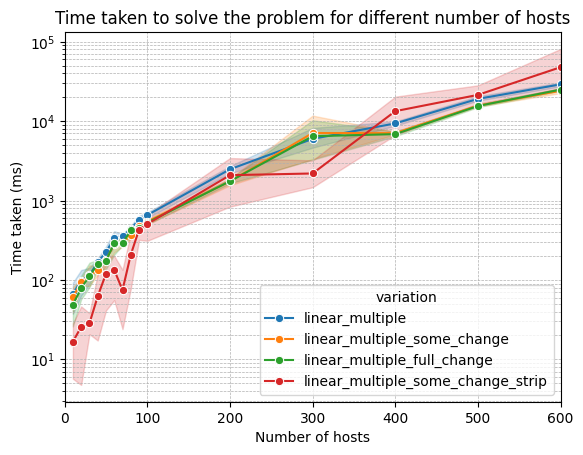

In [5]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

# ax.set_ylim(0, 150)

ax.set_xlim(0, 600)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

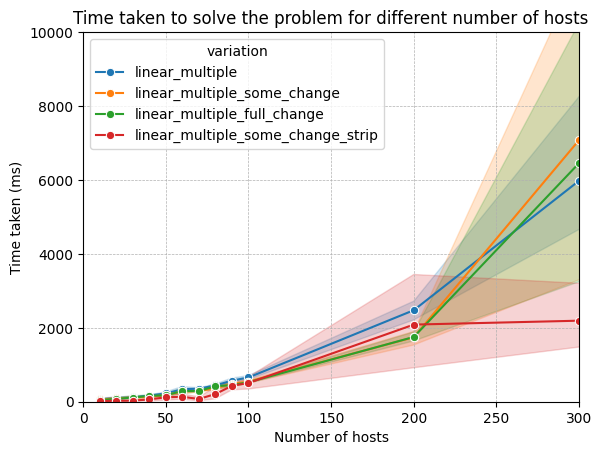

In [8]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
# ax.set_yscale('linear')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 10000)

ax.set_xlim(0, 300)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

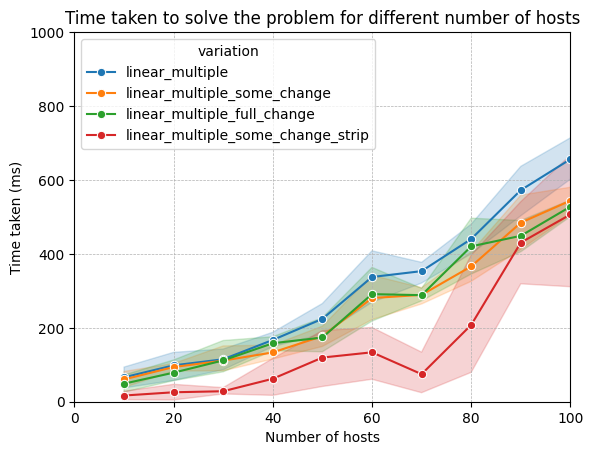

In [13]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
# ax.set_yscale('linear')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 1000)

ax.set_xlim(0, 100)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [17]:
df.loc[df['n_hosts'] >= 400].groupby(['n_hosts', 'variation'])[['time_taken']].mean() / 1000

time_taken
n_hosts variation                                    
400     linear_multiple                      9.364697
        linear_multiple_full_change          6.863909
        linear_multiple_some_change          7.065373
        linear_multiple_some_change_strip   13.353988
500     linear_multiple                     19.077751
        linear_multiple_full_change         15.511845
        linear_multiple_some_change         15.713123
        linear_multiple_some_change_strip   21.421640
600     linear_multiple                     29.059723
        linear_multiple_full_change         24.977262
        linear_multiple_some_change         24.130851
        linear_multiple_some_change_strip   47.814885

In [19]:
data = []

# Read the file line by line
with open("temp_log.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)

df.loc[df['n_hosts'] >= 100].groupby(['n_hosts', 'variation'])[['time_taken']].mean() / 1000

time_taken
n_hosts variation                              
100     linear_multiple                0.534507
        linear_multiple_full_change    0.456680
        linear_multiple_some_change    0.499485
200     linear_multiple                2.100013
        linear_multiple_full_change    1.806911
        linear_multiple_some_change    1.365335
300     linear_multiple                4.139554
        linear_multiple_full_change    3.499236
        linear_multiple_some_change    3.611551
400     linear_multiple                9.491332
        linear_multiple_full_change    7.159157
        linear_multiple_some_change    6.785611
500     linear_multiple               20.258507
        linear_multiple_full_change   17.890360
        linear_multiple_some_change   16.033366
600     linear_multiple               34.497872
        linear_multiple_full_change   26.666331
        linear_multiple_some_change   25.350592

In [12]:
data = []

# Read the file line by line
with open("logs/scale_experiment_single_obj.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.DataFrame(data)
df

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
0,single_obj,100,65,791,184.668303,"[0.01605423424777716, 0.3769888063843326, 1.07...",[2]
1,single_obj_some_change,100,65,791,1053.293228,"[0.01605423424777716, 0.3769888063843326, 1.07...",[2]
2,single_obj_full_change,100,65,791,1059.655190,"[0.0038999745046269696, 1.0409454007851793, 1....",[2]
3,single_obj,200,130,2091,311.590433,"[1.9760508637230334, 0.8214858960095516, 0.857...",[2]
4,single_obj_some_change,200,130,2091,4215.957403,"[1.9760508637230334, 0.8214858960095516, 0.857...",[2]
...,...,...,...,...,...,...,...
750,single_obj_some_change,4000,2600,42221,7281.056643,"[1.5071539836987662, 0.2871889642177582, 0.905...",[2]
751,single_obj_full_change,4000,2600,42221,8849.465132,"[1.3246660103050032, 0.43661645473565236, 0.77...",[2]
752,single_obj,5000,3250,53081,69627.458811,"[1.1382031676368314, 0.22515772794654415, 2.01...",[2]
753,single_obj_some_change,5000,3250,53081,11226.957560,"[1.1382031676368314, 0.22515772794654415, 2.01...",[2]


In [13]:
# drop all rows where n_hosts is equal or more than 100 and less than 400
df = df.drop(df[(df['n_hosts'] >= 100) & (df['n_hosts'] <= 400)].index)
df

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
10,single_obj,500,325,4985,1362.771273,"[2.33560649528197, 1.0980041954995445, 0.14458...",[2]
11,single_obj,600,390,6396,2022.292137,"[0.44651503748322874, 0.793515627660589, 2.761...",[2]
12,single_obj,700,455,7120,2350.403786,"[1.2045737004022743, 0.6259437008013271, 0.764...",[2]
13,single_obj,800,520,8178,2898.411989,"[0.9300790011991726, 0.1448977185167429, 0.538...",[2]
14,single_obj,900,585,10417,3327.149630,"[0.5692134508367905, 0.4870351890398446, 2.351...",[2]
...,...,...,...,...,...,...,...
750,single_obj_some_change,4000,2600,42221,7281.056643,"[1.5071539836987662, 0.2871889642177582, 0.905...",[2]
751,single_obj_full_change,4000,2600,42221,8849.465132,"[1.3246660103050032, 0.43661645473565236, 0.77...",[2]
752,single_obj,5000,3250,53081,69627.458811,"[1.1382031676368314, 0.22515772794654415, 2.01...",[2]
753,single_obj_some_change,5000,3250,53081,11226.957560,"[1.1382031676368314, 0.22515772794654415, 2.01...",[2]


In [14]:
df[(df['n_hosts'] >= 100) & (df['n_hosts'] < 400)]

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status


In [15]:
data = []

# Read the file line by line
with open("logs/scale_experiment_single_obj_.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.concat([df, pd.DataFrame(data)])
df

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
10,single_obj,500,325,4985,1362.771273,"[2.33560649528197, 1.0980041954995445, 0.14458...",[2]
11,single_obj,600,390,6396,2022.292137,"[0.44651503748322874, 0.793515627660589, 2.761...",[2]
12,single_obj,700,455,7120,2350.403786,"[1.2045737004022743, 0.6259437008013271, 0.764...",[2]
13,single_obj,800,520,8178,2898.411989,"[0.9300790011991726, 0.1448977185167429, 0.538...",[2]
14,single_obj,900,585,10417,3327.149630,"[0.5692134508367905, 0.4870351890398446, 2.351...",[2]
...,...,...,...,...,...,...,...
205,single_obj_some_change,400,260,4453,493.401527,"[0.2484573970912116, 0.5493183028839915, 1.549...",[2]
206,single_obj_full_change,400,260,4453,531.381607,"[0.3026876301872359, 0.27863876098180074, 1.13...",[2]
207,single_obj,400,260,4481,1036.309242,"[1.2957087727563958, 2.4239096840794927, 2.332...",[2]
208,single_obj_some_change,400,260,4481,446.097136,"[1.2957087727563958, 2.4239096840794927, 2.332...",[2]


In [16]:
# Initialize an empty list to store each JSON object
data = []

# Read the file line by line
with open("logs/scale_experiment_variating_inputs2.json", "r") as file:
    for line in file:
        # Convert each line (JSON object) to a Python dict and append to the list
        d = json.loads(line)
        # d["result"] = d["result"]["status"]
        data.append(d)

# Convert the list of dicts to a DataFrame
df = pd.concat([df, pd.DataFrame(data)])

# Display the DataFrame
display(df)

,variation,n_hosts,n_tenants,n_workers,time_taken,tenant_loads,status
10,single_obj,500,325,4985,1362.771273,"[2.33560649528197, 1.0980041954995445, 0.14458...",[2]
11,single_obj,600,390,6396,2022.292137,"[0.44651503748322874, 0.793515627660589, 2.761...",[2]
12,single_obj,700,455,7120,2350.403786,"[1.2045737004022743, 0.6259437008013271, 0.764...",[2]
13,single_obj,800,520,8178,2898.411989,"[0.9300790011991726, 0.1448977185167429, 0.538...",[2]
14,single_obj,900,585,10417,3327.149630,"[0.5692134508367905, 0.4870351890398446, 2.351...",[2]
...,...,...,...,...,...,...,...
295,linear_multiple_some_change_strip,600,39,506,26849.874973,"[0.30401069462161323, 0.6529581902891429, 1.77...","[2, 2, 2]"
296,linear_multiple,600,390,6620,27575.907469,"[0.6108968297509425, 2.3358887433118696, 1.898...","[2, 2, 2]"
297,linear_multiple_some_change,600,390,6620,21668.031693,"[0.6108968297509425, 2.3358887433118696, 1.898...","[2, 2, 2]"
298,linear_multiple_full_change,600,390,6620,23863.576412,"[0.30553718246295164, 1.3675825674061697, 2.46...","[2, 2, 2]"


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

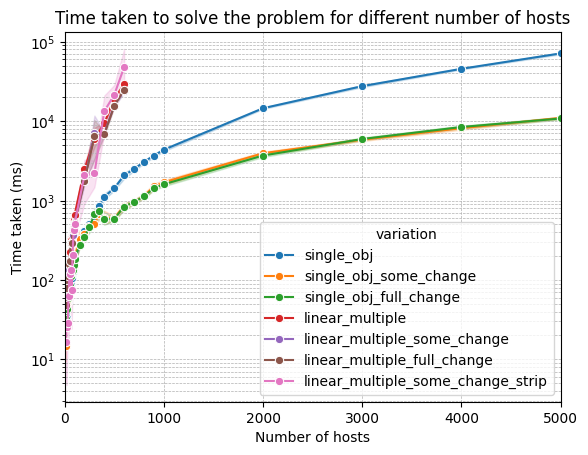

In [17]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

# ax.set_ylim(0, 150)

ax.set_xlim(0, 5000)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [ ]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

# ax.set_ylim(0, 150)

ax.set_xlim(0, 1000)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

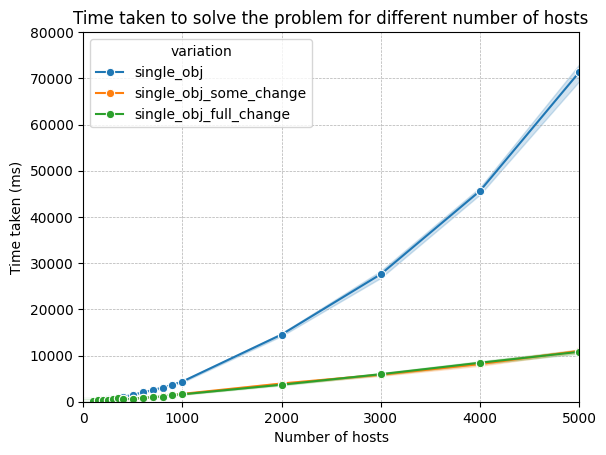

In [7]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
# ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 80000)

ax.set_xlim(0, 5000)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

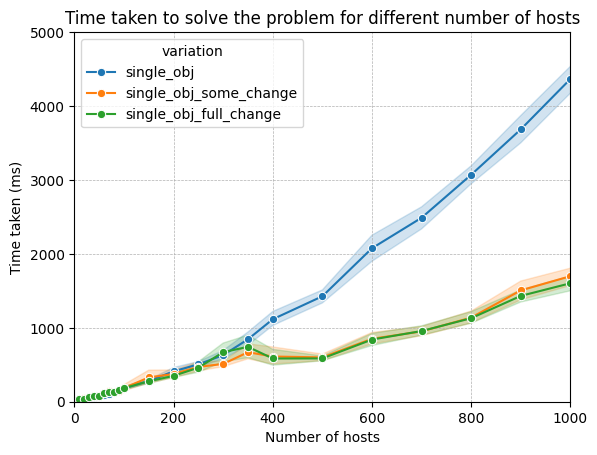

In [8]:
# have an exponential y axis

fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=df, x='n_hosts', y='time_taken', marker='o', hue='variation')
# ax.set_yscale('log')
ax.set_xlabel("Number of hosts")
ax.set_ylabel("Time taken (ms)")
ax.set_title("Time taken to solve the problem for different number of hosts")

ax.set_ylim(0, 5000)

ax.set_xlim(0, 1000)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()